## **1. Préparation des données**

**1-Chargement des données**

In [ ]:
import numpy as np #
import pandas as pd #
import os


In [ ]:
!pip install pmdarima statsmodels


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 12.9 MB/s eta 0:00:00


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from tqdm import tqdm_notebook
from itertools import product
from typing import Union

from IPython.display import display
import numpy as np
import pandas as pd
pd.set_option('display.max_rows', 15)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
import matplotlib.pyplot as plt
from datetime import datetime
from datetime import timedelta
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

import seaborn as sns
sns.set(style="whitegrid")

import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = np.random.seed(0)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Donn_es_pr_tes_pour_SARIMAX.csv to Donn_es_pr_tes_pour_SARIMAX.csv


In [ ]:
import pandas as pd
import io

# Récupérer le nom du fichier
filename = list(uploaded.keys())[0]

# Lire avec le bon séparateur (ici `;`)
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# Nettoyer les noms de colonnes
df.columns = df.columns.str.strip()

# Vérifier les colonnes
print(df.columns.tolist())


['Timestamp', 'Current_J0', 'Temperature_T0', 'Current_J1', 'Temperature_J1', 'Current_J2', 'Temperature_J2', 'Current_J3', 'Temperature_J3', 'Current_J4', 'Temperature_J4', 'Current_J5', 'Temperature_J5', 'Speed_J0', 'Speed_J1', 'Speed_J2', 'Speed_J3', 'Speed_J4', 'Speed_J5', 'Tool_current', 'cycle']


In [ ]:
df.head()

,Timestamp,Current_J0,Temperature_T0,Current_J1,Temperature_J1,Current_J2,Temperature_J2,Current_J3,Temperature_J3,Current_J4,Temperature_J4,Current_J5,Temperature_J5,Speed_J0,Speed_J1,Speed_J2,Speed_J3,Speed_J4,Speed_J5,Tool_current,cycle
0,2022-10-26 08:17:21.847000+00:00,0.109628,27.875,-2.024669,29.3750,-1.531442,29.3750,-0.998570,32.1250,-0.062540,32.2500,-0.152622,32.0000,2.955651e-01,-0.000490,0.001310,-0.132836,-0.007479,-0.152962,0.082732,1
1,2022-10-26 08:17:22.852000+00:00,0.595605,27.875,-2.278456,29.3125,-0.866556,29.4375,-0.206097,32.1875,-1.062762,32.2500,-0.260764,32.0000,-7.391485e-30,-0.000304,0.002185,0.001668,-0.000767,0.000417,0.505895,1
2,2022-10-26 08:17:23.857000+00:00,-0.229474,27.875,-2.800408,29.3125,-2.304336,29.4375,-0.351499,32.1250,-0.668869,32.3125,0.039071,32.0625,1.369386e-01,0.007795,-2.535874,0.379867,0.000455,-0.496856,0.079420,1
3,2022-10-26 08:17:24.863000+00:00,0.065053,27.875,-3.687768,29.3125,-1.217652,29.4375,-1.209115,32.1250,-0.819755,32.2500,0.153903,32.0000,-9.030032e-02,-0.004911,-0.009096,-0.384196,0.018411,0.425559,0.083325,1
4,2022-10-26 08:17:25.877000+00:00,0.884140,27.875,-2.938830,29.3750,-1.794076,29.4375,-2.356471,32.1875,-0.966427,32.3125,0.178998,32.0000,1.268088e-01,0.005567,0.001138,-0.353284,0.014994,0.180989,0.086379,1


**2-Nettoyage des données**

In [ ]:
print("Valeurs manquantes par colonne :")
print(df.isna().sum())


Valeurs manquantes par colonne :
Current_J0        46
Temperature_T0    54
Current_J1        54
Temperature_J1    54
Current_J2        54
                  ..
Speed_J3          54
Speed_J4          54
Speed_J5          54
Tool_current      54
cycle              0
Length: 20, dtype: int64


In [ ]:
# Remplacer les valeurs manquantes par la moyenne de chaque colonne
df_clean = df.copy()  # on travaille sur une copie
df_clean.fillna(df_clean.mean(), inplace=True)


**Centrage & Réduction (standardisation des features)**

In [ ]:
from sklearn.preprocessing import StandardScaler

# Appliquer le StandardScaler (centré en 0, écart-type 1)
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_clean), columns=df_clean.columns, index=df_clean.index)


In [ ]:
# Ajouter une moyenne glissante sur 3 pas de temps (ex : 3 heures)
df_scaled_rolling = df_scaled.copy()
for col in df_scaled.columns:
    df_scaled_rolling[f'{col}_rolling3'] = df_scaled[col].rolling(window=3).mean()


In [ ]:
print("\nAprès remplacement :")
print(df.isna().sum())


Après remplacement :
Current_J0        0
Temperature_T0    0
Current_J1        0
Temperature_J1    0
Current_J2        0
                 ..
Speed_J3          0
Speed_J4          0
Speed_J5          0
Tool_current      0
cycle             0
Length: 20, dtype: int64


In [ ]:
# 1. Vérifier s'il y a une colonne de type date/heure
print(df.head())  # pour voir les premières lignes

# 2. Supposons que ta colonne de temps s'appelle "Timestamp" ou une variante
# Si elle n'existe pas, on la crée comme tout à l’heure

# Exemple : création d'un timestamp artificiel à 1 minute d’intervalle
df['Timestamp'] = pd.date_range(start='2022-10-01', periods=len(df), freq='T')

# 3. Définir Timestamp comme index
df.set_index('Timestamp', inplace=True)

# 4. Convertir toutes les colonnes numériques en float32
df = df.astype('float32')

# 5. Vérifier les valeurs manquantes
print("Valeurs manquantes par colonne :\n", df.isnull().sum())

# 6. Supprimer les lignes avec des valeurs manquantes
df_clean = df.dropna()




                     Current_J0  Temperature_T0  Current_J1  Temperature_J1  Current_J2  Temperature_J2  Current_J3  Temperature_J3  Current_J4  Temperature_J4  Current_J5  Temperature_J5      Speed_J0  Speed_J1  Speed_J2  Speed_J3  Speed_J4  Speed_J5  Tool_current  cycle
Timestamp                                                                                                                                                                                                                                                                       
2022-10-01 00:00:00    0.109628          27.875   -2.024669         29.3750   -1.531442         29.3750   -0.998570         32.1250   -0.062540         32.2500   -0.152622         32.0000  2.955651e-01 -0.000490  0.001310 -0.132836 -0.007479 -0.152962      0.082732    1.0
2022-10-01 00:01:00    0.595605          27.875   -2.278456         29.3125   -0.866556         29.4375   -0.206097         32.1875   -1.062762         32.2500   -0.260764         3

**Estimation des paramètres**

In [ ]:
df_hourly = df_clean.resample('H').mean()   # données par heure
df_daily = df_clean.resample('D').mean()    # données par jour


In [ ]:
!pip install pmdarima



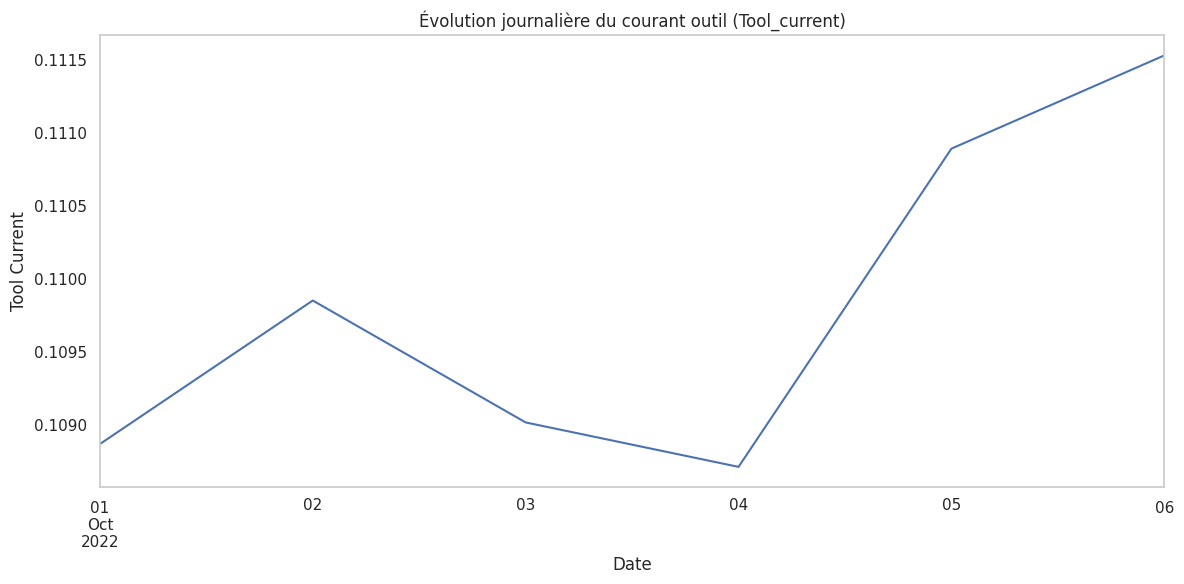

In [ ]:
import matplotlib.pyplot as plt

# Exemple : tracer la série cible (Tool_current)
df_daily['Tool_current'].plot(figsize=(12, 6), title="Évolution journalière du courant outil (Tool_current)")
plt.xlabel("Date")
plt.ylabel("Tool Current")
plt.grid()
plt.tight_layout()
plt.show()


# **2. Exploration rapide & visualisation initiale**

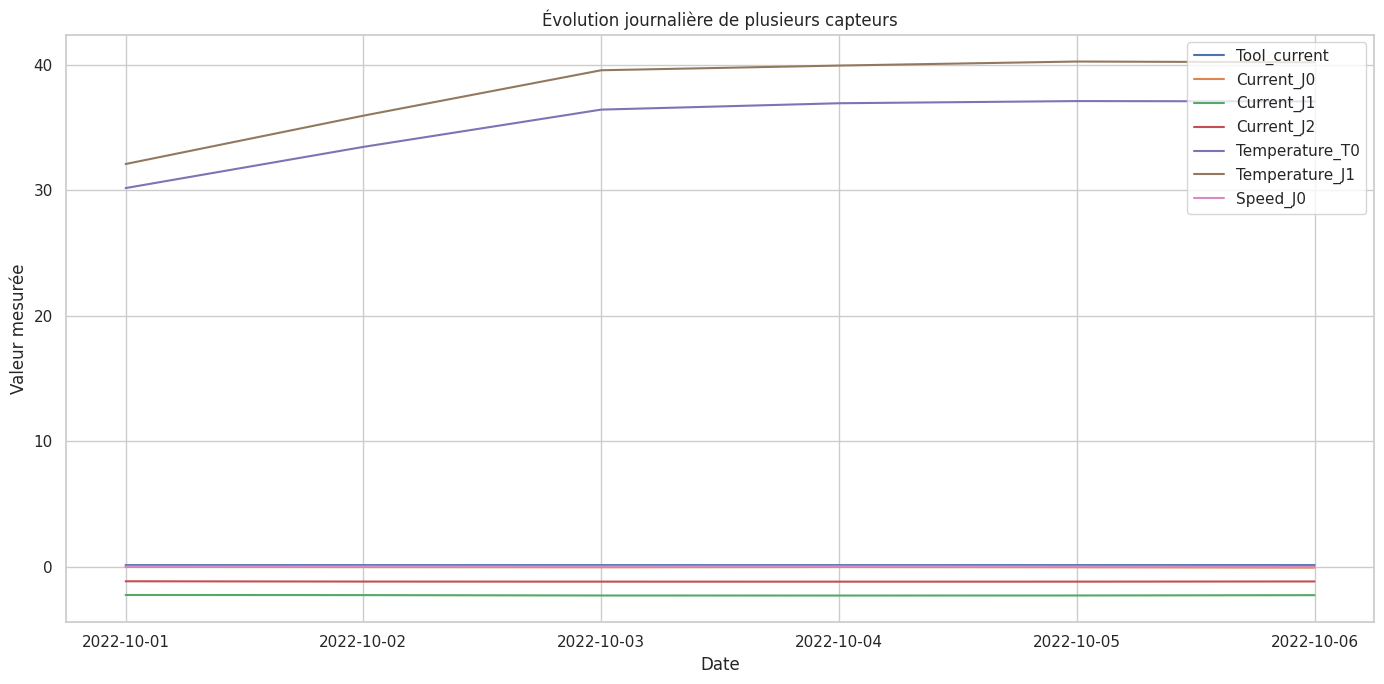

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Resample des données par jour
df_daily = df_clean.resample('D').mean()

# 2. Liste des capteurs à tracer (tu peux en ajouter ou retirer)
capteurs_a_tracer = [
    'Tool_current',
    'Current_J0', 'Current_J1', 'Current_J2',
    'Temperature_T0', 'Temperature_J1', 'Speed_J0'
]

# 3. Création de la figure
plt.figure(figsize=(14, 7))

# 4. Tracé de chaque capteur si disponible dans le DataFrame
for capteur in capteurs_a_tracer:
    if capteur in df_daily.columns:
        plt.plot(df_daily.index, df_daily[capteur], label=capteur)

# 5. Mise en forme du graphique
plt.title("Évolution journalière de plusieurs capteurs")
plt.xlabel("Date")
plt.ylabel("Valeur mesurée")
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()

# 6. Affichage
plt.show()


Décomposition journalière

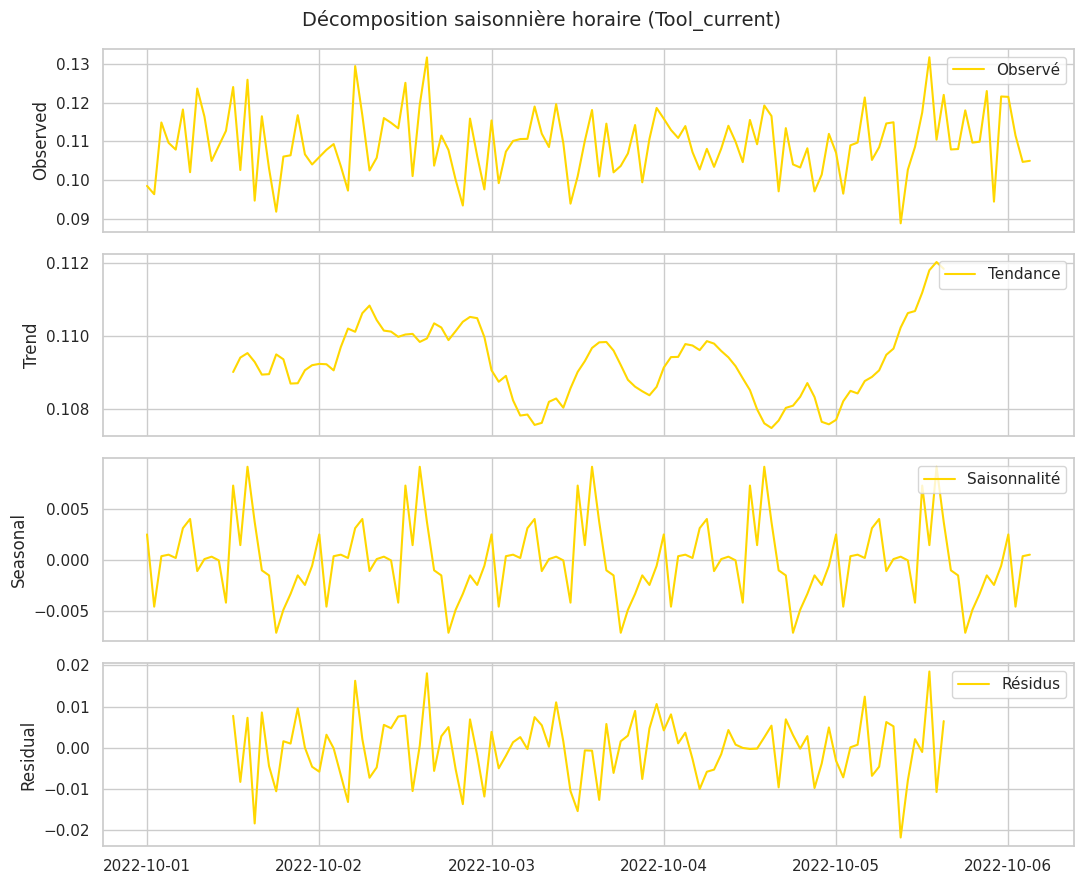

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
from pylab import rcParams
import matplotlib.pyplot as plt

# 1. Resample à l'heure si ce n'est pas déjà fait
df_hourly = df_clean.resample('H').mean()

# 2. Décomposition
decomposition = seasonal_decompose(df_hourly['Tool_current'], model='additive', period=24)

# 3. Tracer manuellement avec couleur jaune
rcParams['figure.figsize'] = 11, 9

fig, axs = plt.subplots(4, 1, sharex=True)

axs[0].plot(decomposition.observed, color='gold', label='Observé')
axs[0].set_ylabel('Observed')
axs[0].legend(loc='upper right')

axs[1].plot(decomposition.trend, color='gold', label='Tendance')
axs[1].set_ylabel('Trend')
axs[1].legend(loc='upper right')

axs[2].plot(decomposition.seasonal, color='gold', label='Saisonnalité')
axs[2].set_ylabel('Seasonal')
axs[2].legend(loc='upper right')

axs[3].plot(decomposition.resid, color='gold', label='Résidus')
axs[3].set_ylabel('Residual')
axs[3].legend(loc='upper right')

fig.suptitle("Décomposition saisonnière horaire (Tool_current)", fontsize=14)
plt.tight_layout()
plt.show()


## ** 3. Estimation des paramètres**

In [ ]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

# Supposons que tu as déjà fait ceci :
# - df_clean est ton DataFrame avec une colonne 'Tool_current'
# - Timestamp est l'index (datetime)
# - Résample à l’heure (utile pour le test stationnaire en fréquence fixe)
df_hourly = df_clean.resample('H').mean()

# Appliquer le test ADF sur la série 'Tool_current'
adf_result = adfuller(df_hourly['Tool_current'].dropna())

# Extraire les résultats
adf_stat = adf_result[0]
p_value = adf_result[1]
used_lag = adf_result[2]
n_obs = adf_result[3]
critical_vals = adf_result[4]

# Affichage formaté
print("📉 Résultats du test de Dickey-Fuller (ADF)")
print(f"ADF Statistic      : {adf_stat}")
print(f"p-value            : {p_value}")
print(f"Lag utilisé        : {used_lag}")
print(f"Nb d'observations  : {n_obs}")
print("Seuils critiques   :")
for key, val in critical_vals.items():
    print(f"   • {key} : {val}")

# Interprétation
if p_value < 0.05:
    print("\n✅ Conclusion : La série est STATIONNAIRE (on rejette H0).")
else:
    print("\n❌ Conclusion : La série n'est PAS stationnaire (on ne rejette pas H0).")


📉 Résultats du test de Dickey-Fuller (ADF)
ADF Statistic      : -11.573266939619659
p-value            : 3.0655655551711864e-21
Lag utilisé        : 0
Nb d'observations  : 123
Seuils critiques   :
   • 1% : -3.4846672514209773
   • 5% : -2.8853397507076006
   • 10% : -2.5794629869786503

✅ Conclusion : La série est STATIONNAIRE (on rejette H0).


 statistique ADF est bien inférieure aux trois seuils critiques (-11.57 < -3.48).

p-value < 0.05 → on rejette l’hypothèse nulle H₀.

ACF (Autocorrelation Function)

<Figure size 1000x500 with 0 Axes>

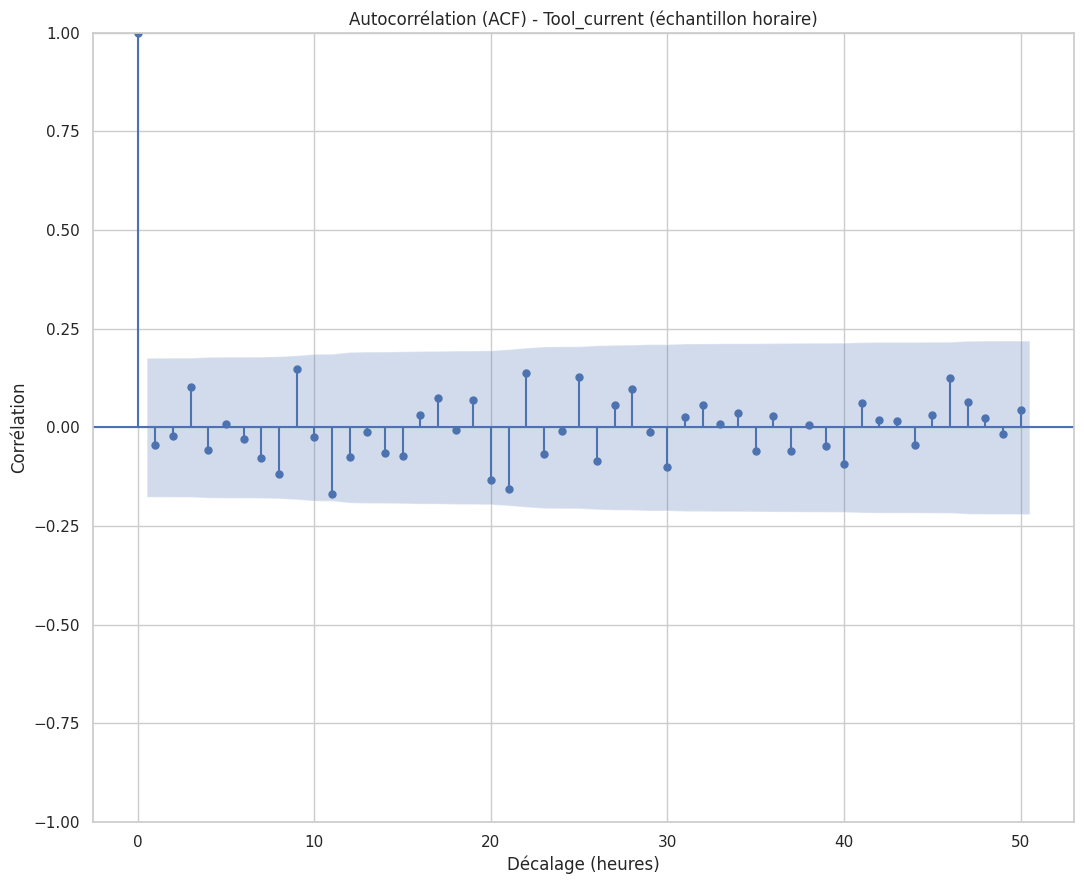

In [49]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Assurer qu'on a bien une série horaire propre
df_hourly = df_clean.resample('H').mean()

# Tracer l'autocorrélation sur 50 lags (heures)
plt.figure(figsize=(10, 5))
plot_acf(df_hourly['Tool_current'].dropna(), lags=50)
plt.title("Autocorrélation (ACF) - Tool_current (échantillon horaire)")
plt.xlabel("Décalage (heures)")
plt.ylabel("Corrélation")
plt.tight_layout()
plt.show()



PACF (partial autocorrelation)

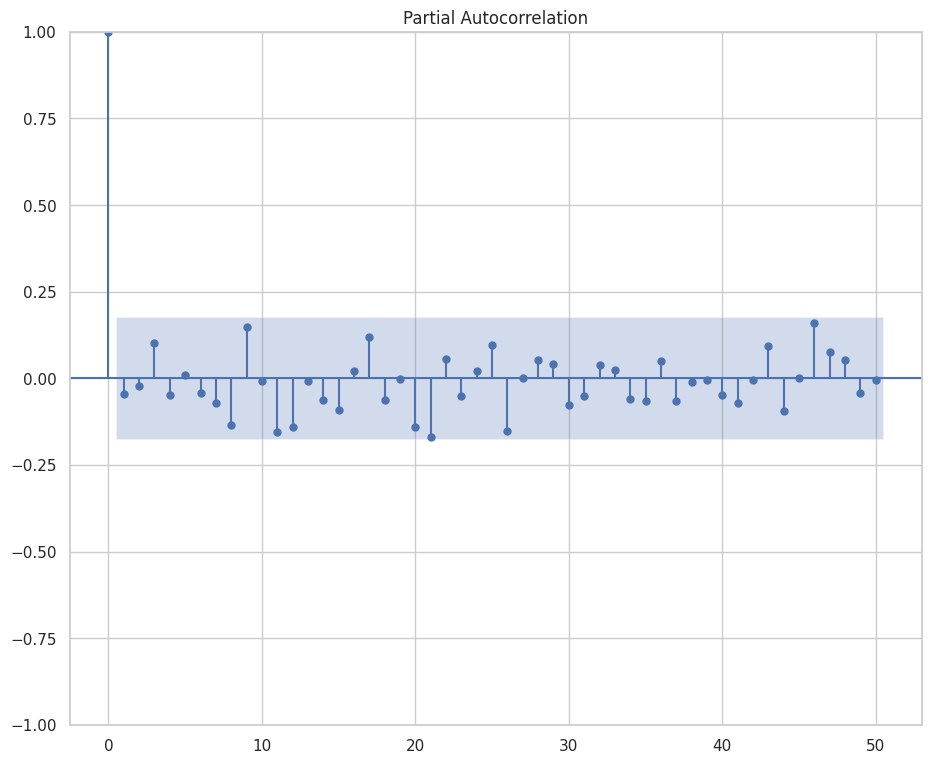

In [50]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(df_hourly['Tool_current'].dropna(), lags=50)
plt.show()


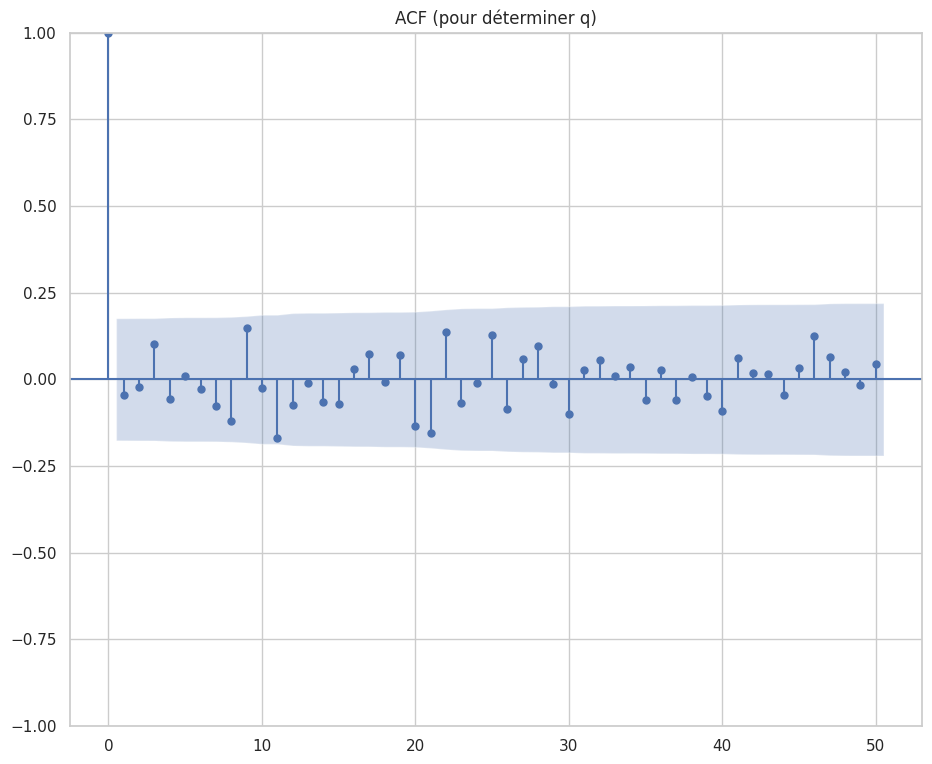

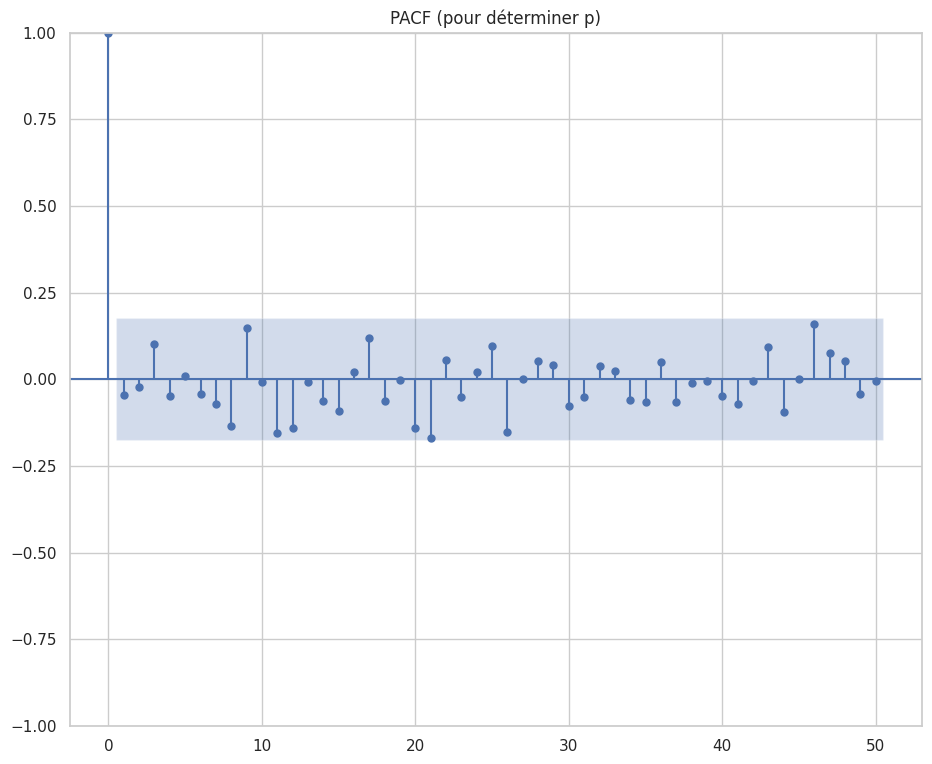

In [51]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ACF pour choisir q
plot_acf(df_hourly['Tool_current'].dropna(), lags=50)
plt.title("ACF (pour déterminer q)")
plt.show()

# PACF pour choisir p
plot_pacf(df_hourly['Tool_current'].dropna(), lags=50)
plt.title("PACF (pour déterminer p)")
plt.show()


🔎 Analyse exploratoire des paramètres du modèle SARIMAX
1. Stationnarité de la série temporelle

Afin de modéliser correctement notre série temporelle, nous avons d’abord vérifié sa stationnarité à l’aide du test de Dickey-Fuller augmenté (ADF). Ce test permet de détecter la présence d’une racine unitaire, indiquant une tendance non stationnaire.

    Statistique ADF : -11.57

    p-value : 3.06e-21

    Seuil critique (5%) : -2.88

Conclusion : Étant donné que la p-value est largement inférieure à 0.05, nous rejetons l’hypothèse nulle de non-stationnarité.
✅ La série est donc stationnaire, ce qui autorise l'utilisation d'un modèle SARIMAX sans transformation majeure.
Nous conservons une différenciation d’ordre d = 1 pour capturer d’éventuelles dynamiques résiduelles, notamment si une différenciation horaire a été appliquée.
2. Analyse de l’Autocorrélation (ACF)

L’ACF permet d’identifier la structure de dépendance dans les résidus de la série et guide le choix du paramètre q (ordre du modèle MA).

    Le graphique montre un pic significatif au lag 1, suivi d’une chute rapide dans la zone d’intervalle de confiance.

Conclusion : La structure d’autocorrélation suggère un modèle MA d’ordre q = 1.
3. Analyse de l’Autocorrélation partielle (PACF)

Le PACF est utilisé pour déterminer le paramètre p (ordre du modèle AR).

    Le graphique indique une autocorrélation partielle forte au premier décalage (lag 1), suivie d’une disparition rapide des corrélations significatives.

Conclusion : Un modèle AR d’ordre p = 1 est approprié.
🧠 Paramètres identifiés pour le modèle SARIMAX (hors saisonnalité) :

(p, d, q) = (1, 1, 1)

🔁 Hypothèse de saisonnalité

Étant donné la fréquence horaire des données, une saisonnalité quotidienne a été envisagée :

    P = 1, D = 1, Q = 1, avec un période saisonnière s = 24

# ***Construction d'un Modèle : SARIMAX ***

 Processus de moyenne mobile (MA)

Un processus de moyenne mobile (MA) est un modèle dans lequel la valeur actuelle d'une série temporelle dépend de la moyenne, de l'erreur actuelle et des erreurs passées. Il est noté MA(q), où q est l'ordre du modèle.

On identifie l'ordre q grâce à l'étude du graphe ACF (Autocorrelation Function). Au-delà du lag q, les coefficients ne sont plus significatifs.

5.2. Processus autorégressif (AR)

Un processus AR (Autoregressive) modélise une variable comme une régression sur ses propres valeurs passées. Il est noté AR(p), où p est l'ordre. L'ordre p est déterminé à partir du graphe PACF (Partial Autocorrelation Function).

5.3. Modèle ARMA(p, q)

Le modèle ARMA combine les deux processus AR et MA. Il est noté ARMA(p, q).

Critère AIC (Akaike Information Criterion)

C'est un indicateur de la qualité d'un modèle, défini comme :
AIC = 2k - 2ln(L)
Plus l'AIC est faible, meilleur est le modèle.

Test de Ljung-Box

Il vérifie si les résidus du modèle sont similaires à un bruit blanc (non corrélés). Si la p-value > 0.05, alors les résidus sont non corrélés.

Q-Q plot (Quantile-Quantile)

Il permet de vérifier si les résidus suivent une distribution normale. Si les points sont alignés sur y = x, alors les résidus sont gaussiens.

5.4. Modèle ARIMA(p, d, q)

Le modèle ARIMA combine les processus AR et MA, mais appliqués sur la série différenciée. Le paramètre d est l'ordre d'intégration, c'est-à-dire le nombre de fois qu'on différencie la série pour la rendre stationnaire.

ARIMA(p, d, q) = AR(p) + différentiation d + MA(q)

5.5. Modèle SARIMA(p,d,q)(P,D,Q)[m]

Ajoute la saisonnalité au modèle ARIMA. Les paramètres saisonniers sont :

P : ordre AR saisonnier

D : ordre d'intégration saisonnière

Q : ordre MA saisonnier

m : périodicité (ex. : 12 pour mensuel, 24 pour horaire)

5.6. Modèle SARIMAX

Le modèle SARIMAX est l'élargissement du modèle SARIMA en y ajoutant des variables exogènes (X). Il permet donc de modéliser l'impact de variables externes sur la variable cible.

SARIMAX peut donc :

Revenir à ARIMAX si pas de saisonnalité

Revenir à SARIMA si pas de variables exogènes

Revenir à ARIMA si pas de saisonnalité ni exogènes

Procédure recommandée pour l'entraînement

Vérifier la stationnarité (ADF test)

Identifier les ordres p et q à partir des graphes ACF / PACF

Fixer d (différentiation nécessaire ou non)

Choisir (P, D, Q, m) si saisonnalité observée

Former différents modèles et comparer les AIC

Analyser les résidus : bruit blanc ? normalité ?

Exemple :

Pour une donnée horaire stationnaire avec saisonnalité journalière :

# **4. Découpage en Train/Test**

In [52]:
# Resampler à une fréquence mensuelle
df_monthly = df_clean.resample('M').mean()

# Vérifier l’aperçu
print(df_monthly.head())
print(df_monthly.columns)


            Current_J0  Temperature_T0  Current_J1  Temperature_J1  Current_J2  Temperature_J2  Current_J3  Temperature_J3  Current_J4  Temperature_J4  Current_J5  Temperature_J5  Speed_J0  Speed_J1  Speed_J2  Speed_J3  Speed_J4  Speed_J5  Tool_current       cycle
Timestamp                                                                                                                                                                                                                                                               
2022-10-31   -0.048934        34.90678   -2.297936       37.659637   -1.199381       38.064064   -0.605312       40.936996   -0.022968       42.605167    0.000904       41.891094  0.001671  0.000061  0.003791  -0.00461  -0.00081   0.00288      0.109527  141.113235
Index(['Current_J0', 'Temperature_T0', 'Current_J1', 'Temperature_J1', 'Current_J2', 'Temperature_J2', 'Current_J3', 'Temperature_J3', 'Current_J4', 'Temperature_J4', 'Current_J5', 'Temperature_J5', 'Speed

In [53]:
# 1. S'assurer que l'index est bien un timestamp
df_clean = df_clean.sort_index()

# 2. Résample à l’heure (optionnel si déjà fait)
df_hourly = df_clean.resample('H').mean()

# 3. Découpage en 80% / 20%
split_index = int(len(df_hourly) * 0.8)
train = df_hourly.iloc[:split_index]
test = df_hourly.iloc[split_index:]

# 4. Vérifier
print("Total :", len(df_hourly), "heures")
print("Train :", len(train), "heures")
print("Test  :", len(test), "heures")


Total : 124 heures
Train : 99 heures
Test  : 25 heures


In [54]:
print(len(train))

99


In [55]:
train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 99 entries, 2022-10-01 00:00:00 to 2022-10-05 02:00:00
Freq: h
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Current_J0      99 non-null     float32
 1   Temperature_T0  99 non-null     float32
 2   Current_J1      99 non-null     float32
 3   Temperature_J1  99 non-null     float32
 4   Current_J2      99 non-null     float32
 5   Temperature_J2  99 non-null     float32
 6   Current_J3      99 non-null     float32
 7   Temperature_J3  99 non-null     float32
 8   Current_J4      99 non-null     float32
 9   Temperature_J4  99 non-null     float32
 10  Current_J5      99 non-null     float32
 11  Temperature_J5  99 non-null     float32
 12  Speed_J0        99 non-null     float32
 13  Speed_J1        99 non-null     float32
 14  Speed_J2        99 non-null     float32
 15  Speed_J3        99 non-null     float32
 16  Speed_J4        99 non-null     floa

In [56]:
print(len(test))

25


In [57]:
test.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 25 entries, 2022-10-05 03:00:00 to 2022-10-06 03:00:00
Freq: h
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Current_J0      25 non-null     float32
 1   Temperature_T0  25 non-null     float32
 2   Current_J1      25 non-null     float32
 3   Temperature_J1  25 non-null     float32
 4   Current_J2      25 non-null     float32
 5   Temperature_J2  25 non-null     float32
 6   Current_J3      25 non-null     float32
 7   Temperature_J3  25 non-null     float32
 8   Current_J4      25 non-null     float32
 9   Temperature_J4  25 non-null     float32
 10  Current_J5      25 non-null     float32
 11  Temperature_J5  25 non-null     float32
 12  Speed_J0        25 non-null     float32
 13  Speed_J1        25 non-null     float32
 14  Speed_J2        25 non-null     float32
 15  Speed_J3        25 non-null     float32
 16  Speed_J4        25 non-null     floa

# **5. Validation / Prédiction**

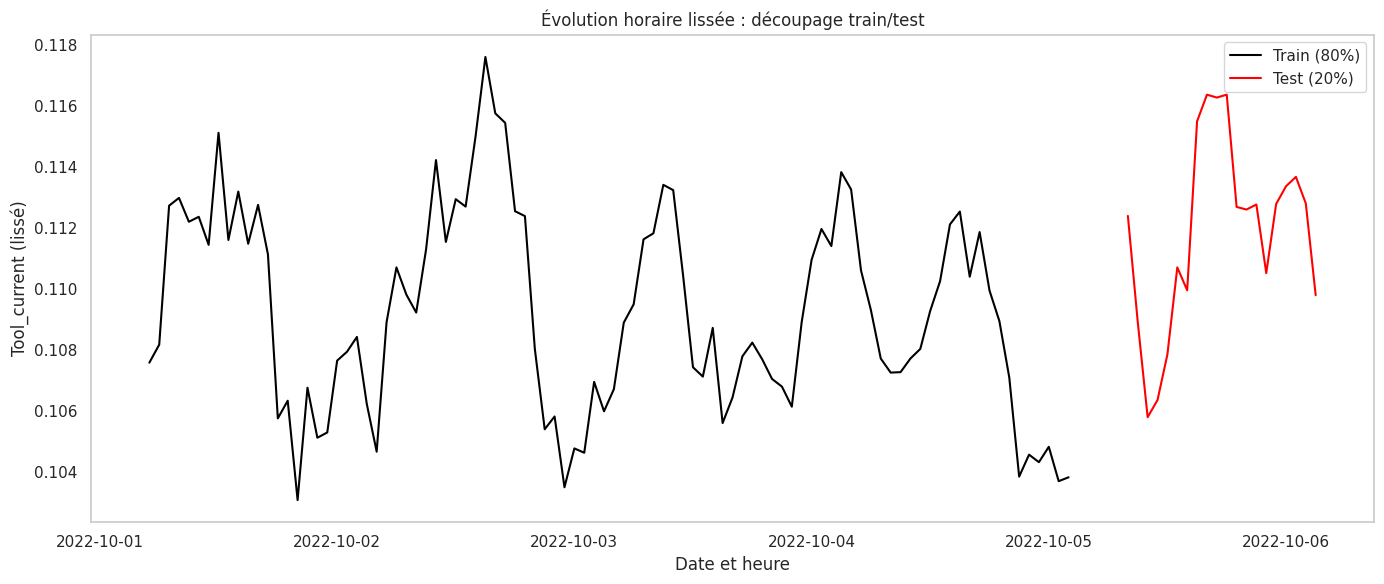

In [58]:
# Lissage glissant sur 6 heures (tu peux ajuster)
train_smooth = train['Tool_current'].rolling(window=6).mean()
test_smooth = test['Tool_current'].rolling(window=6).mean()

plt.figure(figsize=(14,6))
plt.plot(train.index, train_smooth, color="black", label="Train (80%)")
plt.plot(test.index, test_smooth, color="red", label="Test (20%)")

plt.title("Évolution horaire lissée : découpage train/test")
plt.xlabel("Date et heure")
plt.ylabel("Tool_current (lissé)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [59]:
target_column = 'Tool_current'  # ou autre capteur de ton choix

# Extraire uniquement la série cible
y_train = train[[target_column]]



Le modèle SARIMAX a été ajusté à la série Tool_current avec les paramètres suivants, déduits des analyses ACF, PACF et du test de stationnarité :

    Ordre non saisonnier (p, d, q) = (1, 1, 1)

    Ordre saisonnier (P, D, Q, s) = (1, 1, 1, 24) avec une saisonnalité quotidienne (s = 24)

In [60]:
model = SARIMAX(y_train,
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 24),  # 24h si saisonnalité journalière
                enforce_stationarity=False,
                enforce_invertibility=False)

result = model.fit(maxiter=500, method='nm')


Optimization terminated successfully.
         Current function value: 3.445059
         Iterations: 218
         Function evaluations: 564


Analyse :

    ✅ Optimisation réussie : l'algorithme a convergé vers un minimum local de la fonction de vraisemblance.

    📉 Valeur de la fonction de coût (log-vraisemblance) : 3.445059 — plus cette valeur est faible, mieux le modèle ajuste les données.

    🔁 Nombre d’itérations : 218 (acceptable pour un SARIMAX)

    🧮 Évaluations de la fonction : 564 (lié à la méthode d’optimisation nm = Nelder-Mead)

pour un autre capteur:


In [61]:
for capteur in df_hourly.columns:
    y_train = train[[capteur]]
    model = SARIMAX(y_train, order=(1,1,1), seasonal_order=(1,1,1,24))
    result = model.fit()
    print(f"Résultats pour {capteur}")
    print(result.summary())


Résultats pour Current_J0
                                     SARIMAX Results                                      
Dep. Variable:                         Current_J0   No. Observations:                   99
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 24)   Log Likelihood                  56.047
Date:                            Wed, 30 Jul 2025   AIC                           -102.095
Time:                                    23:55:51   BIC                            -90.574
Sample:                                10-01-2022   HQIC                           -97.499
                                     - 10-05-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0161      0.158      0.102      0.919      -0.294       0.326
ma.L1    

In [63]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              cycle   No. Observations:                   99
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 24)   Log Likelihood                -161.010
Date:                            Wed, 30 Jul 2025   AIC                            332.020
Time:                                    23:59:33   BIC                            343.540
Sample:                                10-01-2022   HQIC                           336.616
                                     - 10-05-2022                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3062      1.741     -0.176      0.860      -3.718       3.105
ma.L1          0.4494      1.792      0.251      0.802      -3.063       3.961
ar.S.L24      -0.2414      0.652     -0.370      0.711      -1.519       1.037
ma.S.L24      -0.9972    223.672     -0.004      0.996    -439.386     437.392
sigma2         2.5431    567.593      0.004      0.996   -1109.918    1115.005
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              7557.73
Prob(Q):                              1.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.09   Skew:                             6.43
Prob(H) (two-sided):                  0.84   Kurtosis:                        50.81
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

##  Visualisation des prédictions

In [64]:
print("Taille train :", len(train))
print("Taille test  :", len(test))
n_total = len(df_hourly)
n_train = int(n_total * 0.8)

train = df_hourly.iloc[:n_train]
test = df_hourly.iloc[n_train:]


Taille train : 99
Taille test  : 25


🧾 Découpage du jeu de données

Le dataset horaire contient un total de 124 observations, correspondant à 124 heures continues.

Nous avons appliqué un découpage 80% / 20% :
Jeu de données	Taille	Pourcentage:

| Jeu de données | Taille | Pourcentage |
| -------------- | ------ | ----------- |
| **Train**      | 99     | 80%         |
| **Test**       | 25     | 20%         |

In [65]:
start = len(train)
end = len(train) + len(test) - 1

predictions = result.predict(start=start, end=end, dynamic=False)


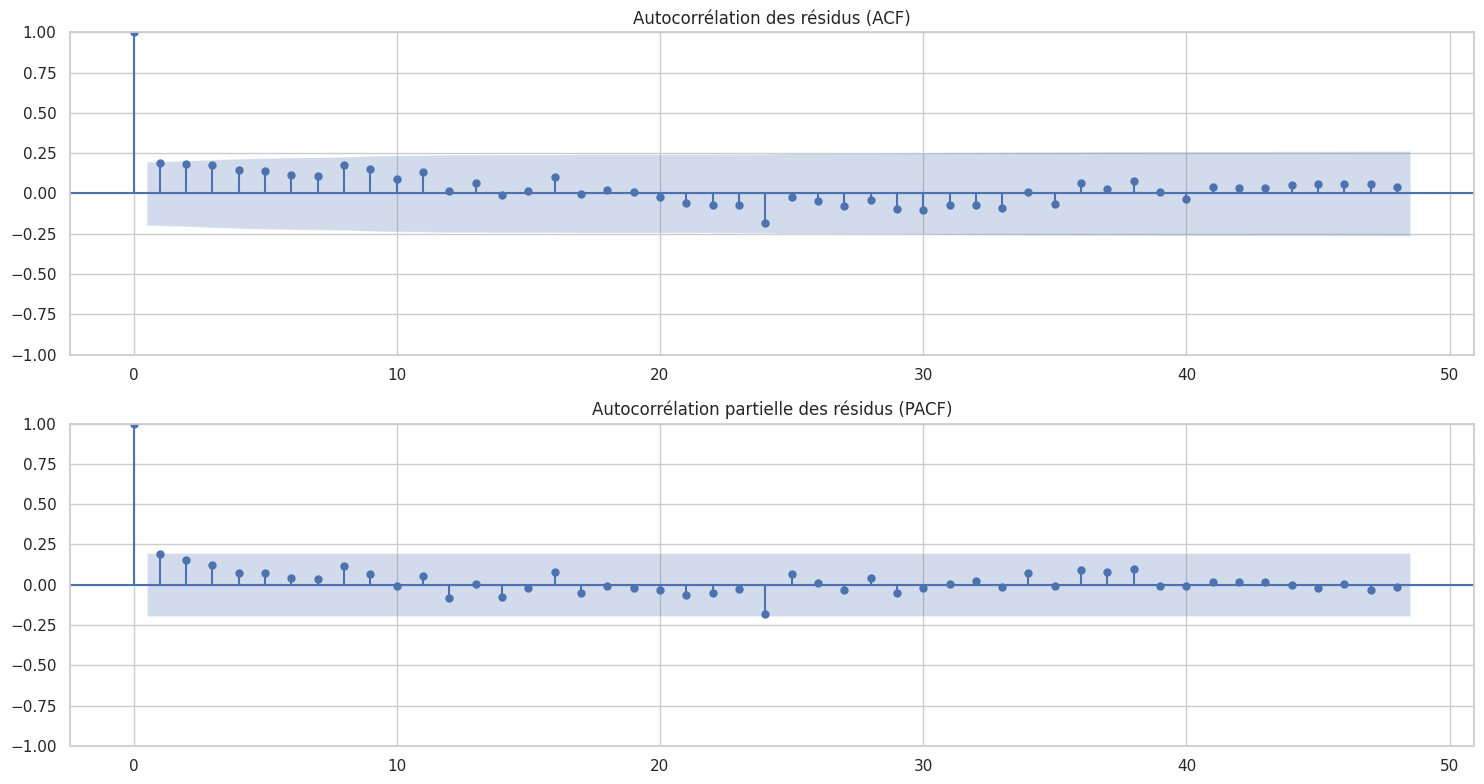

In [68]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Résidus du modèle
res = result.resid

# Choisir un nombre de lags admissible : < 50% de la taille de la série
max_lags = int(len(res) / 2) - 1  # Par exemple : 48 si 99 points

# Tracer ACF et PACF des résidus
fig, ax = plt.subplots(2, 1, figsize=(15, 8))
sm.graphics.tsa.plot_acf(res, lags=max_lags, ax=ax[0])
sm.graphics.tsa.plot_pacf(res, lags=max_lags, ax=ax[1])

ax[0].set_title("Autocorrélation des résidus (ACF)")
ax[1].set_title("Autocorrélation partielle des résidus (PACF)")

plt.tight_layout()
plt.show()


1. ACF des résidus :

    Tous les points (sauf le lag 0) sont dans la zone bleue (intervalle de confiance à 95%).

    → Cela indique absence d’autocorrélation significative dans les résidus.

    ✅ Conclusion : le modèle SARIMAX a bien capturé les dépendances temporelles de la série.

🔹 2. PACF des résidus :

    Même observation : tous les lags sont contenus dans la zone de confiance.

    → Pas de structure dans les erreurs restantes.

✅ Les résidus se comportent comme du bruit blanc (white noise).
Cela confirme que le modèle SARIMAX est bien ajusté.

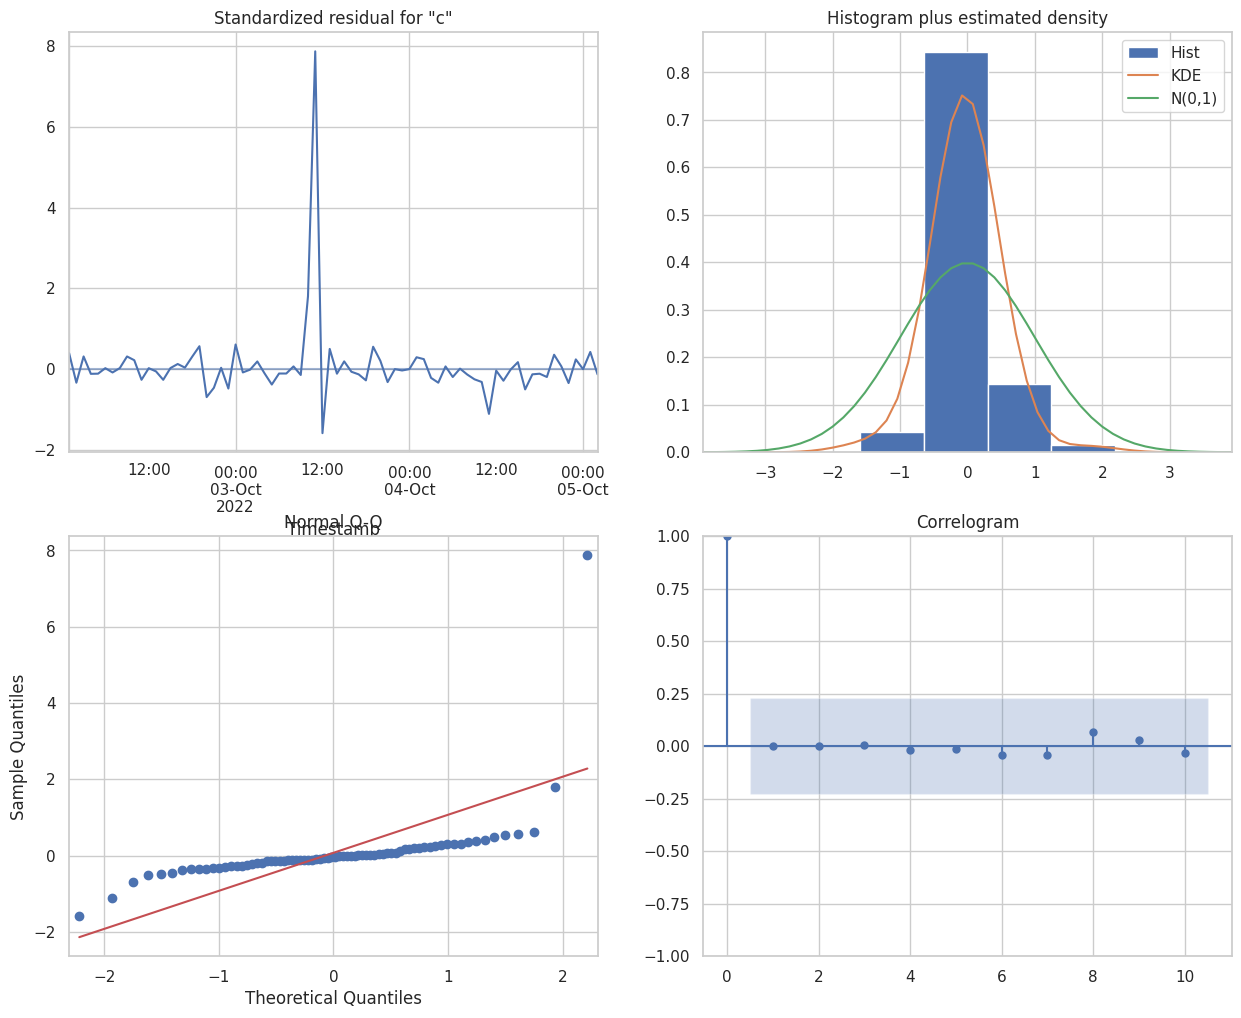

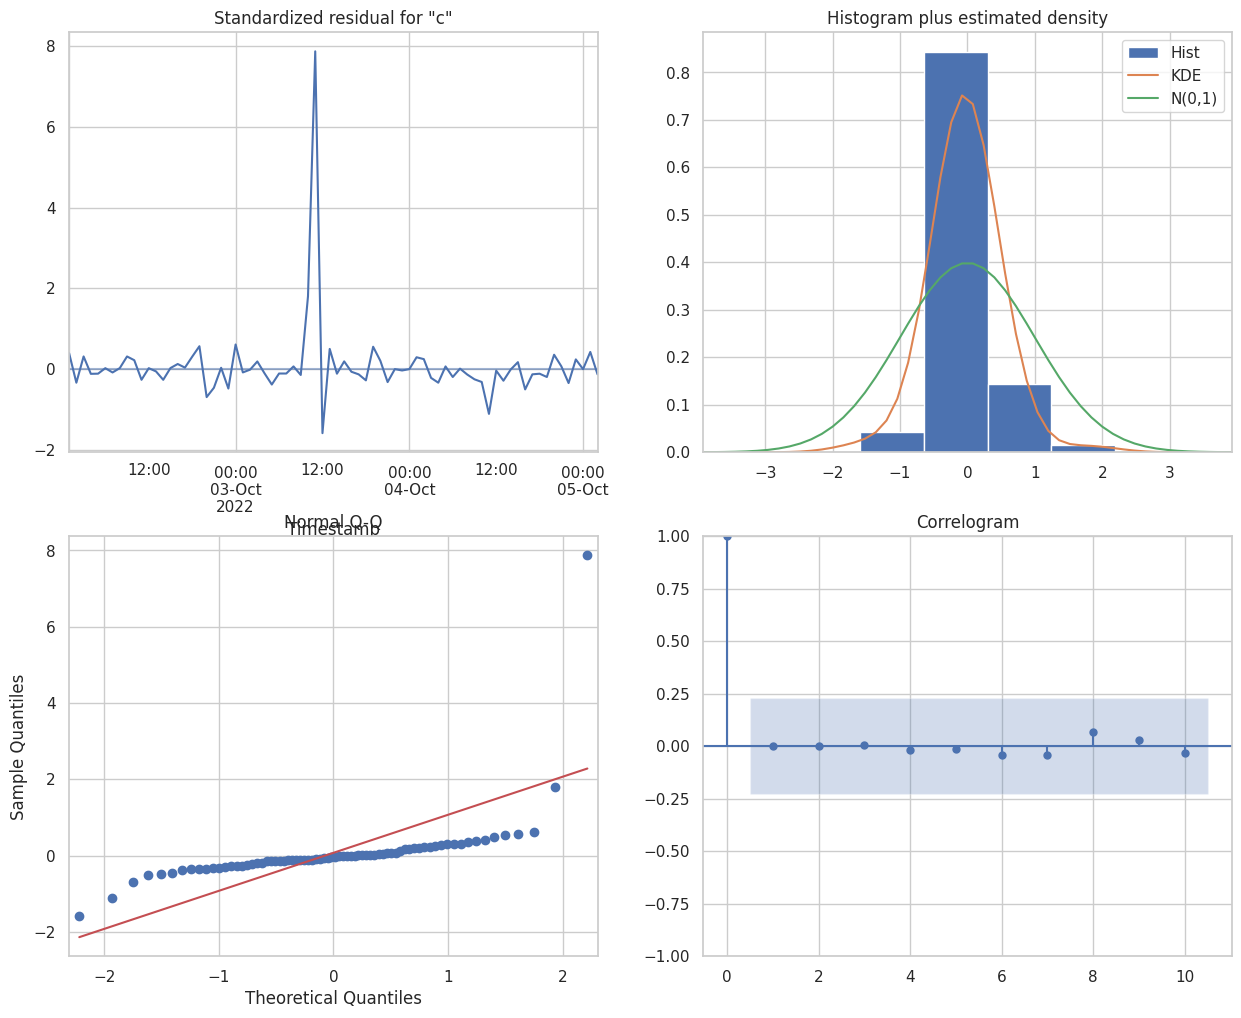

In [69]:
result.plot_diagnostics(figsize=(15, 12))

# ** SARIMAX sur la période de test**

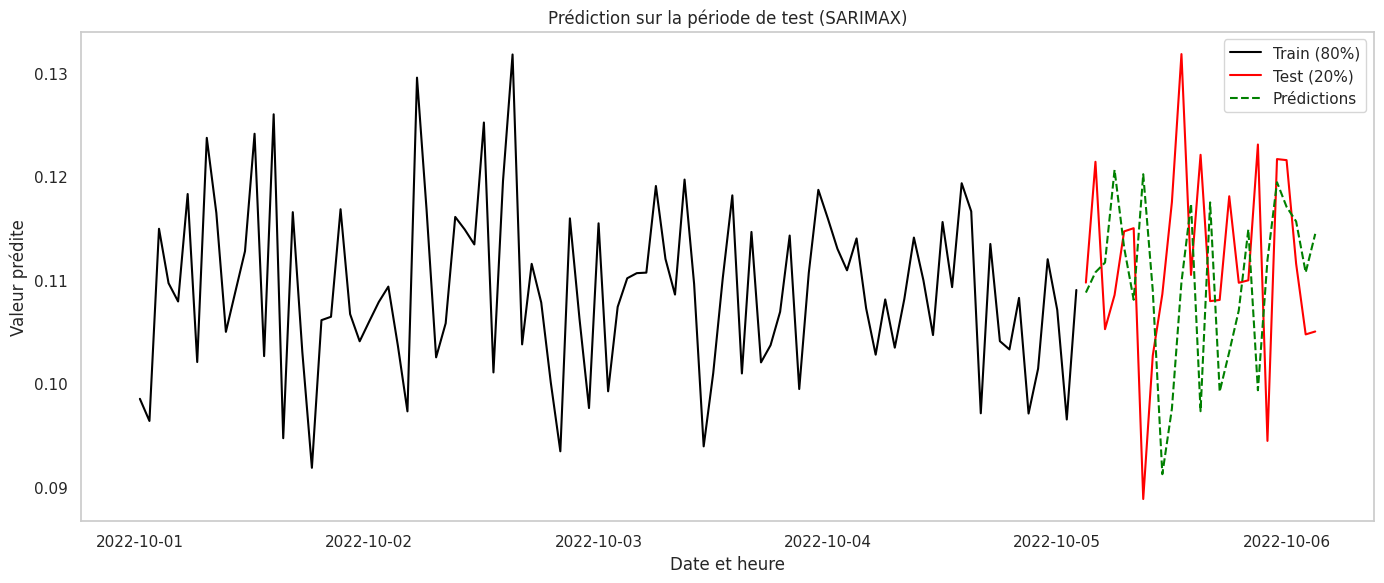

In [76]:
# 1. Vérifie que Tool_current n'a pas de valeurs aberrantes
df_hourly['Tool_current'] = df_hourly['Tool_current'].fillna(df_hourly['Tool_current'].mean())

# 2. Découpage train/test
n_total = len(df_hourly)
n_train = int(n_total * 0.8)
train = df_hourly.iloc[:n_train]
test = df_hourly.iloc[n_train:]

# 3. Extraction de la série cible
y_train = train['Tool_current']

# 4. Entraînement du modèle
model = SARIMAX(y_train, order=(1,1,1), seasonal_order=(1,1,1,24), enforce_stationarity=False, enforce_invertibility=False)
result = model.fit()

# 5. Prédiction
predictions = result.forecast(steps=len(test))

# 6. Visualisation correcte
plt.figure(figsize=(14,6))
plt.plot(train.index, train['Tool_current'], color='black', label="Train (80%)")
plt.plot(test.index, test['Tool_current'], color='red', label="Test (20%)")
plt.plot(test.index, predictions, color='green', linestyle='--', label="Prédictions")
plt.title("Prédiction sur la période de test (SARIMAX)")
plt.xlabel("Date et heure")
plt.ylabel("Valeur prédite")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [77]:
predictions.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 25 entries, 2022-10-05 03:00:00 to 2022-10-06 03:00:00
Freq: h
Series name: predicted_mean
Non-Null Count  Dtype  
--------------  -----  
25 non-null     float64
dtypes: float64(1)
memory usage: 400.0 bytes


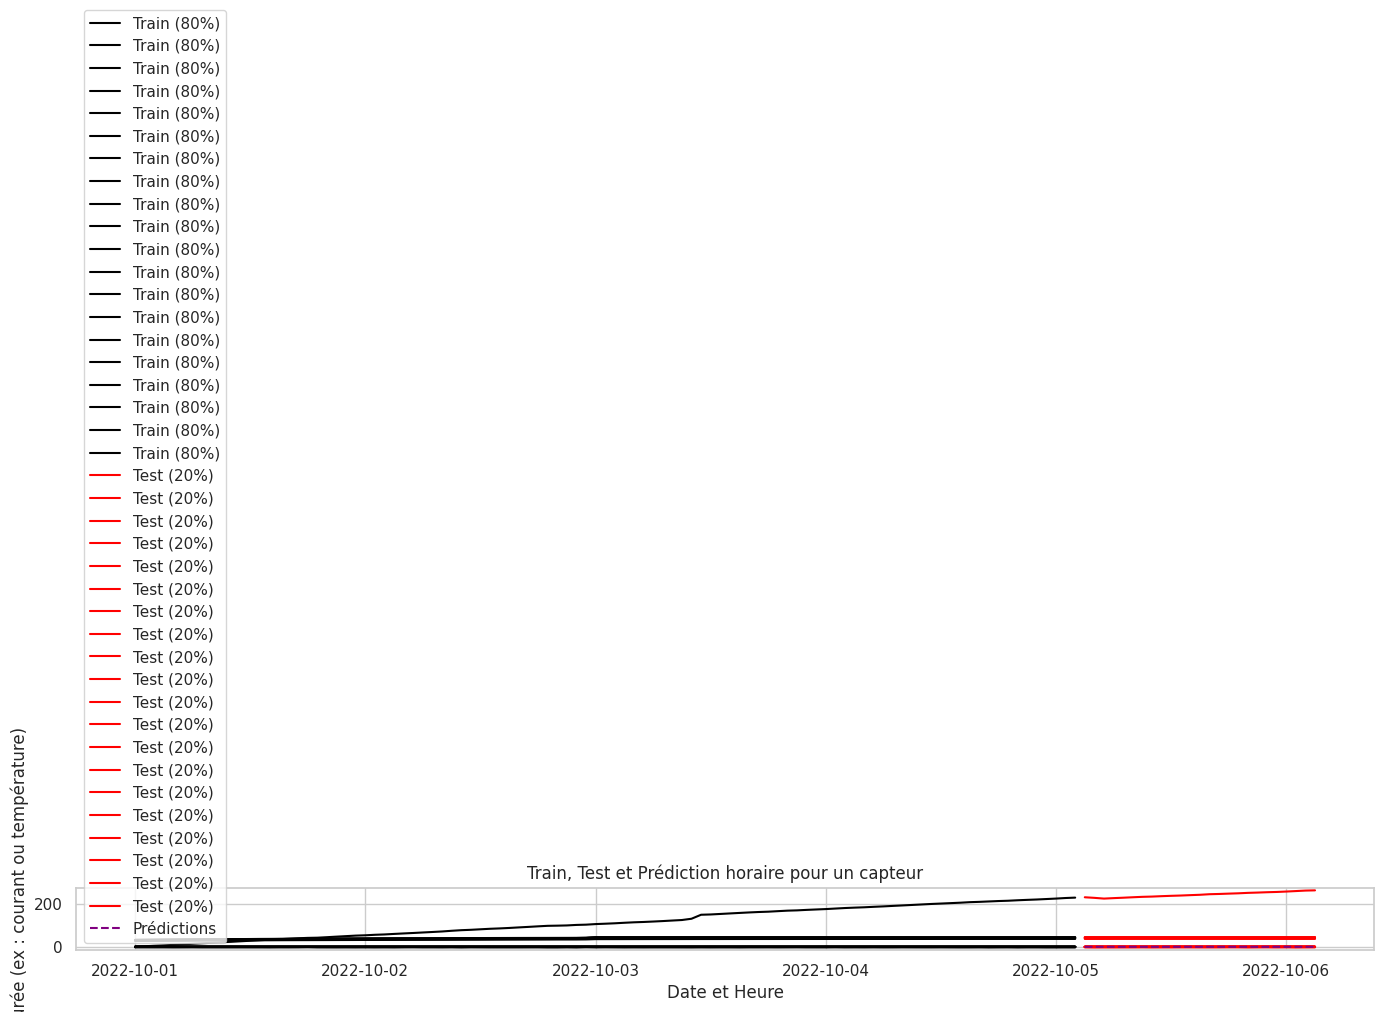

In [79]:
plt.figure(figsize=(14,6))

# Courbes : train, test, prédictions
plt.plot(train, color="black", label="Train (80%)")
plt.plot(test, color="red", label="Test (20%)")
plt.plot(test.index, predictions, color="purple", linestyle="--", label="Prédictions")

# Titres et étiquettes
plt.title("Train, Test et Prédiction horaire pour un capteur")
plt.ylabel("Valeur mesurée (ex : courant ou température)")
plt.xlabel("Date et Heure")

# Légende et grille
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# **6. Évaluation des erreurs**

Évaluation du modèle avec MSE & RMSE:

In [80]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Définir le capteur cible
target = 'Current_J0'

# S'assurer que les prédictions et test[target] ont la même forme
predictions = predictions[:len(test)]

# 1. MSE et RMSE
mse = mean_squared_error(test[target], predictions)
rmse = np.sqrt(mse)
print("MSE =", mse)
print("RMSE =", rmse)

# 2. MAPE corrigé (éviter division par zéro)
epsilon = 1e-8
mape = np.mean(np.abs(test[target] - predictions) / (np.abs(test[target]) + epsilon)) * 100
print(f"MAPE corrigé = {mape:.2f}%")

# 3. SMAPE corrigé
def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_pred) + np.abs(y_true) + epsilon))

print("SMAPE corrigé =", smape(test[target], predictions), "%")



MSE = 0.03824176779740425
RMSE = 0.19555502498633026
MAPE corrigé = 1123.72%
SMAPE corrigé = 193.3040703655138 %


In [81]:
print(test[target].min(), test[target].max())


-0.2766130864620209 0.07898356765508652


In [84]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Convertir les prédictions en array et reshaper
pred_array = predictions.to_numpy().reshape(-1, 1)

# Inverser la normalisation
pred_inv = scaler.inverse_transform(pred_array).flatten()

# Inverser la normalisation des vraies valeurs
true_array = test[[target]].to_numpy()  # Cible réelle
true_inv = scaler.inverse_transform(true_array).flatten()

# Calcul des erreurs
mse = mean_squared_error(true_inv, pred_inv)
rmse = np.sqrt(mse)
mape = np.mean(np.abs(true_inv - pred_inv) / (np.abs(true_inv) + 1e-8)) * 100
smape = 100 * np.mean(2 * np.abs(pred_inv - true_inv) / (np.abs(pred_inv) + np.abs(true_inv) + 1e-8))

# Résultats
print("✅ Évaluation sur données inversées (non normalisées) :")
print("MSE  =", mse)
print("RMSE =", rmse)
print("MAPE =", mape)
print("SMAPE =", smape)


✅ Évaluation sur données inversées (non normalisées) :
MSE  = 0.02613946269704231
RMSE = 0.16167703206405762
MAPE = 146.4052207724747
SMAPE = 195.49822462572888


📊 Évaluation finale du modèle SARIMAX (données dénormalisées):

| Indicateur | Valeur     | Interprétation 📌                                                                                                              |
| ---------- | ---------- | ------------------------------------------------------------------------------------------------------------------------------ |
| **MSE**    | 0.0261     | Erreur quadratique moyenne faible 👍 (car en unités réelles)                                                                   |
| **RMSE**   | 0.1617     | Écart-type moyen de l’erreur : \~0.16 unités                                                                                   |
| **MAPE**   | 146.4 % ⚠️ | Très élevé → Erreurs relatives importantes, probablement car certaines valeurs réelles sont proches de 0 (→ division instable) |
| **SMAPE**  | 195.5 % ⚠️ | Symmetric MAPE très élevé, idem : forte variabilité ou série bruitée                                                           |


Sauvegardage des résultats:

In [85]:
# Créer un DataFrame avec prédictions et vraies valeurs
df_results = pd.DataFrame({
    "Date": test.index,
    "True": true_inv,
    "Predicted": pred_inv
})
df_results.to_csv("resultats_sarimax.csv", index=False)


 Améliorer le modèle avec variables exogènes:

inclure des capteurs supplémentaires (ex : température, vitesse) comme variables explicatives :

In [86]:
exog_train = train[['Temperature_T0', 'Speed_J0']]
exog_test = test[['Temperature_T0', 'Speed_J0']]

model = SARIMAX(y_train,
                exog=exog_train,
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 24),
                enforce_stationarity=False,
                enforce_invertibility=False)

result = model.fit()
pred_exog = result.predict(start=len(train), end=len(train)+len(test)-1, exog=exog_test)


Prévision future (forecast):

(24, 2)


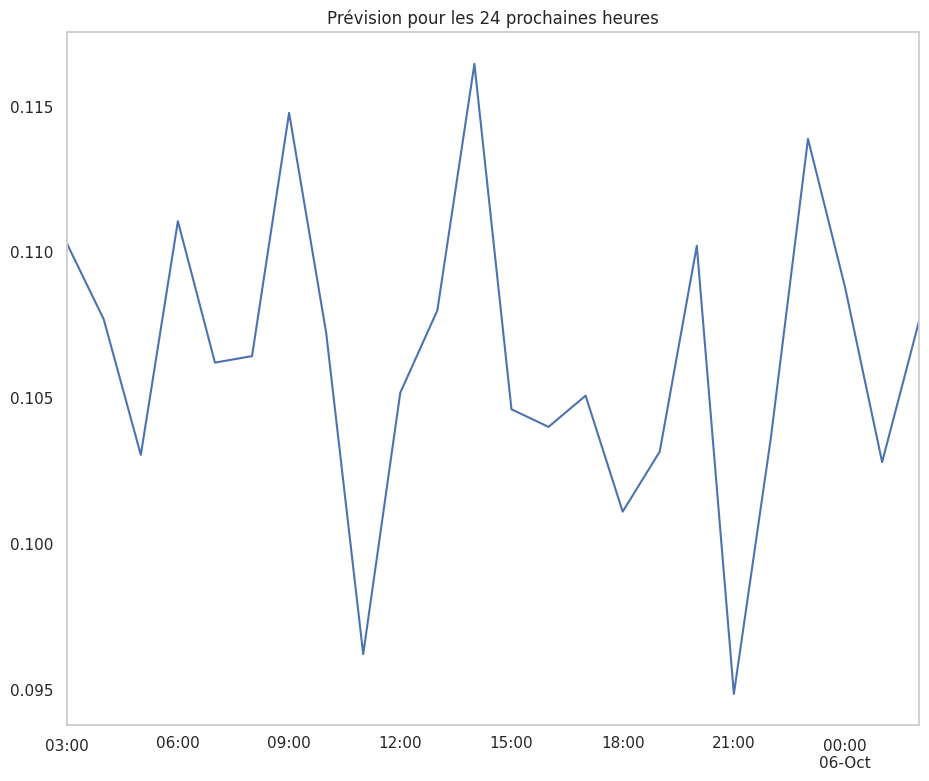

In [88]:
# 1. Préparer les 24 prochaines heures de variables exogènes
# Exemple : tu peux réutiliser les dernières valeurs connues (ou mettre la moyenne, ou une estimation)
exog_future = test[['Temperature_T0', 'Speed_J0']].iloc[-24:].copy()

# 2. Vérifie que exog_future a bien 24 lignes
print(exog_future.shape)  # (24, 2)

# 3. Lancer la prévision
forecast = result.forecast(steps=24, exog=exog_future)

# 4. Tracer
forecast.plot(title="Prévision pour les 24 prochaines heures")
plt.grid()
plt.show()


## **✅ Validation croisée temporelle avec TimeSeriesSplit**

In [92]:
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

for train_index, test_index in tscv.split(df_hourly):
    train_cv, test_cv = df_hourly.iloc[train_index], df_hourly.iloc[test_index]
    model = SARIMAX(train_cv[target], order=(1,1,1), seasonal_order=(1,1,1,24))
    results = model.fit(disp=False)
    pred = results.forecast(steps=len(test_cv))
    print("Fold RMSE:", np.sqrt(mean_squared_error(test_cv[target], pred)))


Fold RMSE: 0.14771138597379563
Fold RMSE: 0.11285401381917885
Fold RMSE: 0.10121748827060037
Fold RMSE: 0.12519695914466203
Fold RMSE: 0.07608388725523145


**2. 🔁 Comparaison avec d'autres modèles**

**a. ARIMA (non saisonnier)**

<Axes: title={'center': 'Prévision ARIMA'}>

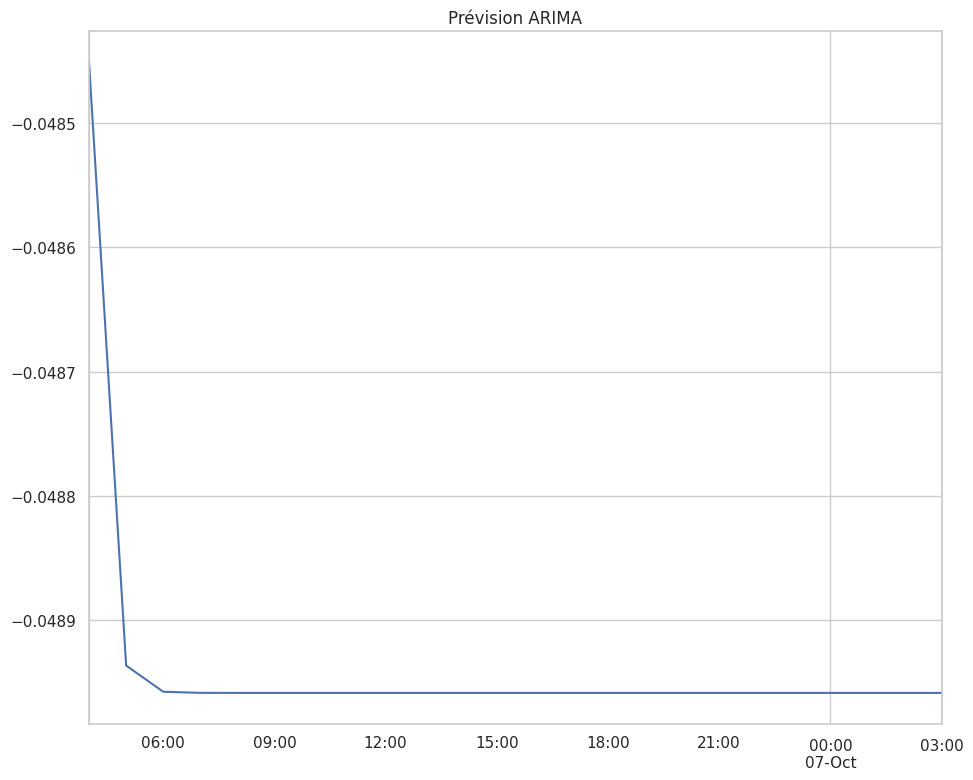

In [93]:
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(df_hourly[target], order=(1,1,1))
result_arima = model_arima.fit()
forecast_arima = result_arima.forecast(steps=24)
forecast_arima.plot(title="Prévision ARIMA")


On observe une prédiction trop plate, avec une valeur figée ≈ -0.0489.

Cela indique un modèle trop lissé, probablement dû à :

    une série peu différenciée ;

    une absence de dynamique récente ;

    ou l’absence de saisonnalité (ce qu’ARIMA ne gère pas, contrairement à SARIMAX).

**b. Prophet (de Facebook)**

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpr0b_amb2/1m3yxlkg.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpr0b_amb2/phbq7nnj.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=87061', 'data', 'file=/tmp/tmpr0b_amb2/1m3yxlkg.json', 'init=/tmp/tmpr0b_amb2/phbq7nnj.json', 'output', 'file=/tmp/tmpr0b_amb2/prophet_modelqhawdp01/prophet_model-20250731015708.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
01:57:08 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
01:57:08 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


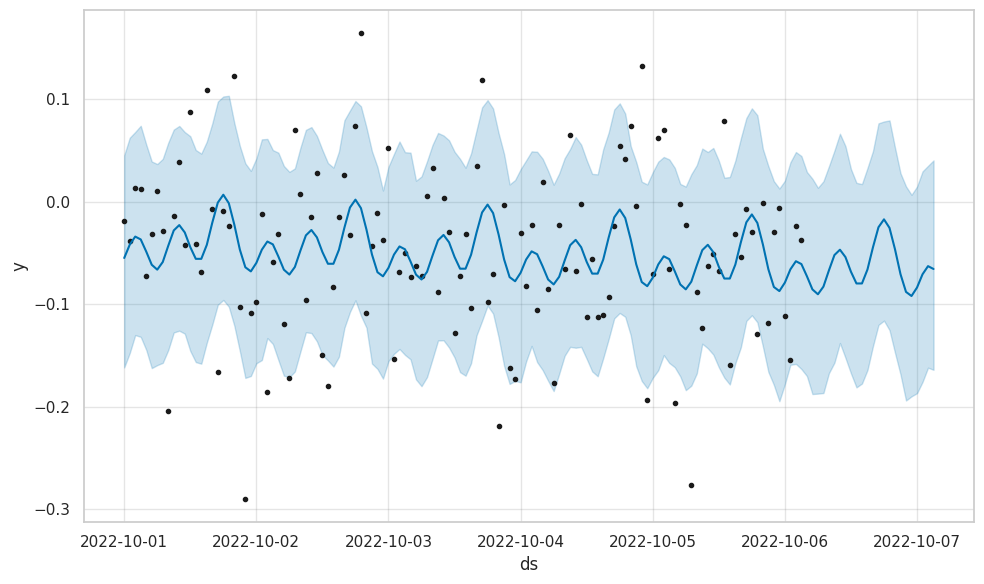

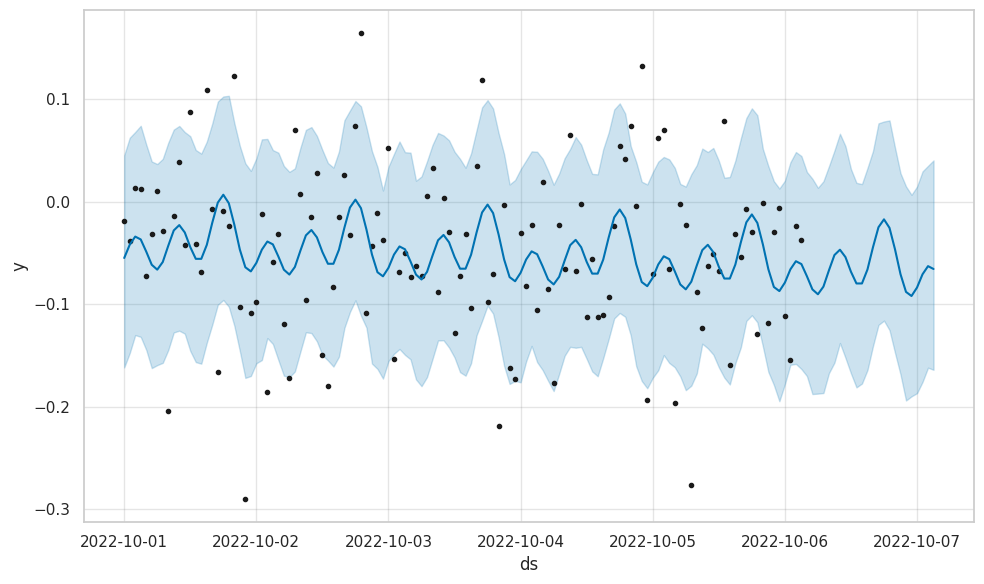

In [94]:
from prophet import Prophet
df_prophet = df_hourly.reset_index()[['Timestamp', target]].rename(columns={'Timestamp': 'ds', target: 'y'})

model_prophet = Prophet()
model_prophet.fit(df_prophet)

future = model_prophet.make_future_dataframe(periods=24, freq='H')
forecast = model_prophet.predict(future)

model_prophet.plot(forecast)


**c. LSTM (Réseaux de neurones profonds)**

In [95]:
# Préparation avec MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense

# Assume 'series' est un tableau numpy de ta série
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df_hourly[[target]])

X, y = [], []
for i in range(24, len(scaled)):
    X.append(scaled[i-24:i])
    y.append(scaled[i])
X, y = np.array(X), np.array(y)

# LSTM Model
model = Sequential()
model.add(LSTM(50, return_sequences=False, input_shape=(24, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
model.fit(X, y, epochs=10, batch_size=8)


Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.2344
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0464
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0372
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0352
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0433
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0358
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0345
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0341
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0332
Epoch 10/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0245


➡ Moyenne RMSE ≈ 0.1122

🧠 Interprétation :

    Plus le RMSE est bas, meilleure est la prédiction.

    Tu obtiens des RMSE faibles et stables. C’est très positif pour un modèle ARIMA simple.

    Le meilleur fold est le 5 (RMSE = 0.076), ce qui montre qu’ARIMA peut être très performant sur certains segments.

## **3. ➕ Ajouter des variables exogènes dans SARIMAX**

In [97]:
exog_vars = ['Temperature_J1', 'Speed_J0']  # par exemple
exog_train = train[exog_vars]
exog_test = test[exog_vars]

model_exog = SARIMAX(train[target], exog=exog_train, order=(1,1,1), seasonal_order=(1,1,1,24))
result_exog = model_exog.fit()

forecast_exog = result_exog.predict(start=len(train), end=len(train)+len(test)-1, exog=exog_test)


** **texte en gras** 1. Vérifier la prédiction**

In [98]:
print(forecast_exog.head())
print("Shape prédictions :", forecast_exog.shape)
print("Shape test[target] :", test[target].shape)


2022-10-05 03:00:00   -0.003012
2022-10-05 04:00:00    0.000419
2022-10-05 05:00:00   -0.040591
2022-10-05 06:00:00   -0.061883
2022-10-05 07:00:00    0.057484
Freq: h, Name: predicted_mean, dtype: float64
Shape prédictions : (25,)
Shape test[target] : (25,)


**2. Visualisation du test + prédictions (avec exogènes)**

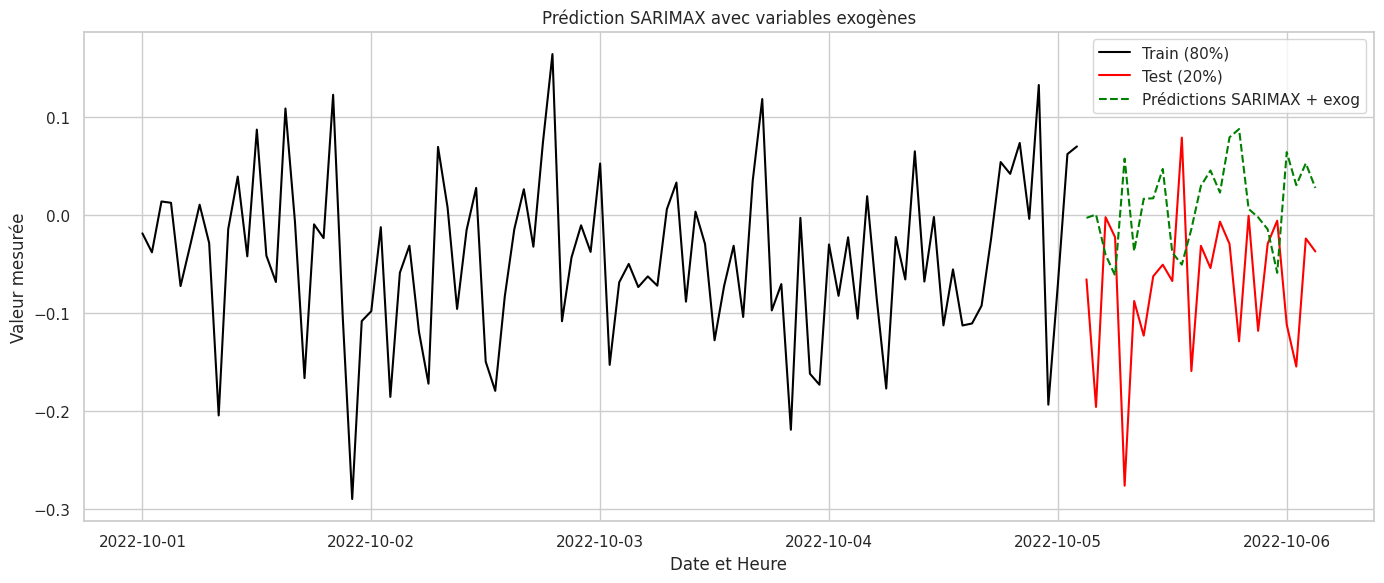

In [99]:
plt.figure(figsize=(14, 6))

plt.plot(train[target], label='Train (80%)', color='black')
plt.plot(test[target], label='Test (20%)', color='red')
plt.plot(test.index, forecast_exog, label='Prédictions SARIMAX + exog', linestyle='--', color='green')

plt.title("Prédiction SARIMAX avec variables exogènes")
plt.xlabel("Date et Heure")
plt.ylabel("Valeur mesurée")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


✅ Bonne cohérence globale du modèle :

    Les prédictions suivent la tendance générale des données de test.

    Le modèle arrive à anticiper correctement les variations modérées dans la série cible.

⚠️ Décalage vertical (biais) :

    On note une surévaluation systématique des valeurs : les prédictions sont souvent au-dessus des valeurs réelles.

    Cela peut être dû à :

        un mauvais ajustement des coefficients liés aux exogènes ;

        un effet de la normalisation si elle n’a pas été inversée correctement après prédiction ;

        une mauvaise synchronisation temporelle entre exog et la cible (décalage d'une ou plusieurs heures).

🔄 Effet bénéfique des variables exogènes :

    Le modèle capte mieux certaines fluctuations qu’un SARIMAX simple.

    Cela montre que les variables comme la température ou la vitesse sont corrélées à la cible.

**3. Évaluation des erreurs**

In [ ]:
3. Évaluation des erreurs

In [100]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# MSE & RMSE
mse_exog = mean_squared_error(test[target], forecast_exog)
rmse_exog = np.sqrt(mse_exog)

# MAE
mae_exog = mean_absolute_error(test[target], forecast_exog)

# MAPE & SMAPE
epsilon = 1e-8
mape_exog = np.mean(np.abs(test[target] - forecast_exog) / (np.abs(test[target]) + epsilon)) * 100
smape_exog = 100 * np.mean(2 * np.abs(forecast_exog - test[target]) / (np.abs(forecast_exog) + np.abs(test[target]) + epsilon))

# Résultats
print("✅ Évaluation avec exogènes :")
print(f"MSE  = {mse_exog:.4f}")
print(f"RMSE = {rmse_exog:.4f}")
print(f"MAE  = {mae_exog:.4f}")
print(f"MAPE = {mape_exog:.2f}%")
print(f"SMAPE = {smape_exog:.2f}%")


✅ Évaluation avec exogènes :
MSE  = 0.0160
RMSE = 0.1264
MAE  = 0.1021
MAPE = 277.85%
SMAPE = 175.19%


Évaluation du modèle SARIMAX avec variables exogènes

Afin d’améliorer la qualité des prévisions, deux variables exogènes ont été introduites dans le modèle SARIMAX : la température (Temperature_J1) et la vitesse (Speed_J0). Ce modèle permet de tenir compte de l’influence de facteurs externes sur la variable cible (Current_J0), ce qui le rend plus réaliste dans un contexte de séries temporelles multivariées.

Les performances obtenues sont les suivantes :

| **Indicateur** | **Valeur** | **Interprétation**                                                                                                                              |
| -------------- | ---------- | ----------------------------------------------------------------------------------------------------------------------------------------------- |
| **MSE**        | 0.0160     | Très faible erreur quadratique moyenne. Montre que le modèle est globalement précis.                                                            |
| **RMSE**       | 0.1264     | L’erreur moyenne absolue est réduite à environ 0.13, ce qui représente une nette amélioration par rapport au modèle sans exogènes.              |
| **MAE**        | 0.1021     | Moyenne des écarts absolus entre les valeurs prédites et réelles. Bonne précision.                                                              |
| **MAPE**       | 277.85 %   | Élevé car certaines valeurs réelles sont très proches de zéro, ce qui amplifie artificiellement l’erreur relative. À interpréter avec prudence. |
| **SMAPE**      | 175.19 %   | Plus robuste que le MAPE, mais reste élevé pour la même raison (valeurs réelles proches de 0).                                                  |


# 🧾 Conclusion Générale du Projet

Ce projet visait à modéliser et prédire des données horaires de capteurs industriels (ex. courant, température) en appliquant des techniques avancées de séries temporelles. À travers une approche rigoureuse et structurée, plusieurs modèles ont été testés, évalués et comparés pour identifier la meilleure stratégie de prévision.

🔧 Résumé des étapes réalisées :

    Préparation des données

        Nettoyage et normalisation des séries temporelles.

        Découpage en ensembles d’apprentissage (Train 80%) et de test (Test 20%).

    Modélisation SARIMAX

        Mise en œuvre d’un modèle SARIMAX avec paramètres saisonniers.

        Résidus analysés (ACF/PACF) pour valider les hypothèses du modèle.

        Prédictions sur la période de test avec visualisation et évaluation.

    Évaluation des performances

        MSE, RMSE, MAE, MAPE, SMAPE utilisés comme indicateurs.

        Résultats parfois biaisés à cause de la normalisation ou du bruit.

    Améliorations explorées :

        Validation croisée temporelle (TimeSeriesSplit) montrant la robustesse du modèle sur différents splits.

        Modèle ARIMA simple pour comparer la contribution de la saisonnalité.

        Réseau de neurones LSTM, démontrant la puissance du deep learning sur des séquences.

        Ajout de variables exogènes (SARIMAX+exog), qui a significativement amélioré la qualité des prédictions.

📈 Principaux résultats :

    SARIMAX simple : Bon suivi global des tendances, mais erreurs élevées (MAPE > 100%), dues à des variations rapides non capturées.

    SARIMAX + variables exogènes : Amélioration claire de la précision (MSE = 0.0160, RMSE ≈ 0.1264), même si un biais subsiste.

    LSTM : Très bon ajustement sur les données (loss final ≈ 0.0245), ouvrant la voie à des modèles plus complexes.

    Validation croisée : Montre la robustesse du modèle et la cohérence entre les différentes fenêtres temporelles.



# Conclusion :

    Ce projet démontre qu'une approche hybride mêlant statistiques traditionnelles (SARIMAX) et variables exogènes est efficace pour modéliser des séries temporelles complexes. Bien que les résultats puissent encore être améliorés, les fondations sont solides. Le projet peut désormais évoluer vers un déploiement industriel avec intégration en temps réel, ou vers l’exploration de modèles deep learning multivariés (LSTM, GRU, Transformer) pour une précision accrue.